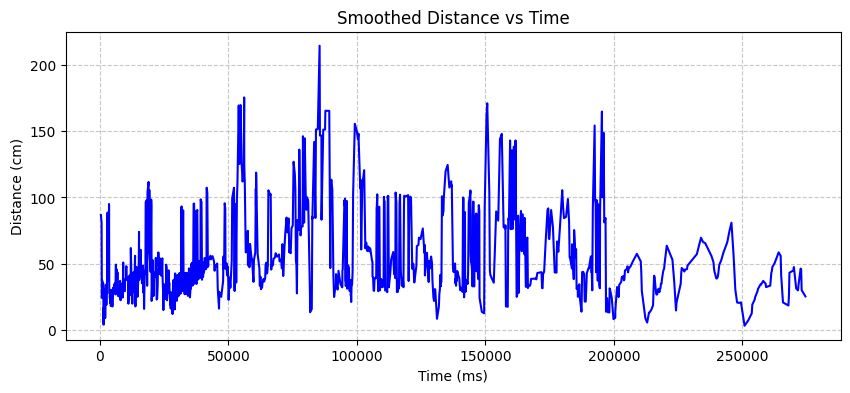

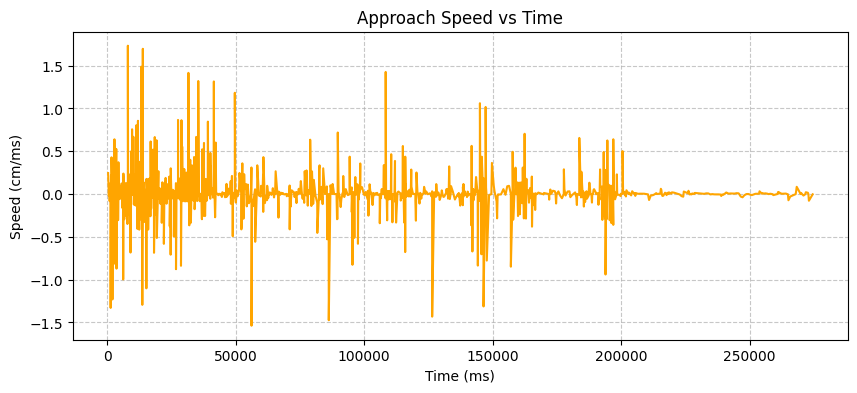

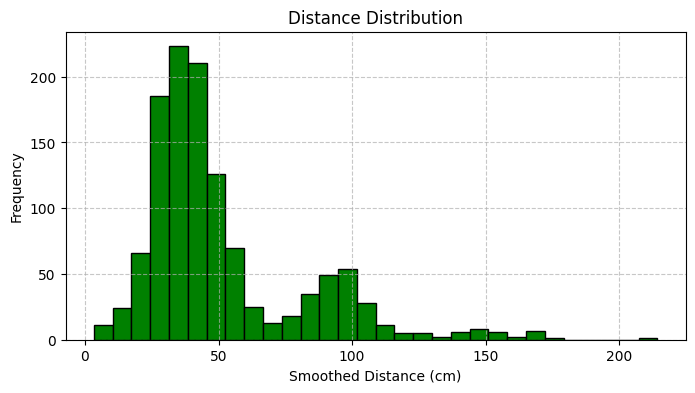

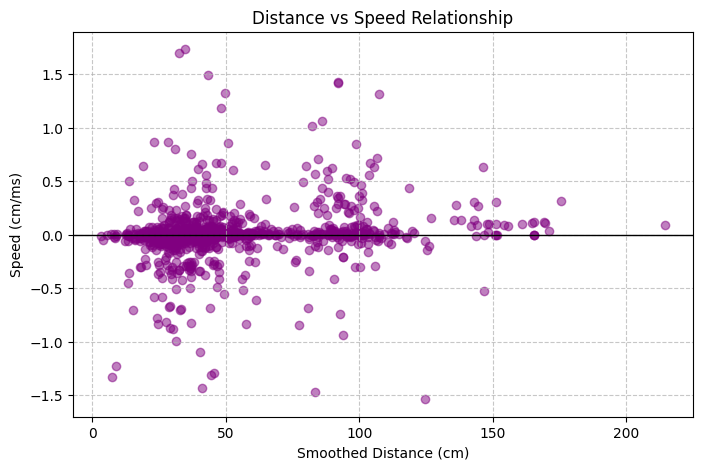

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("../Dataset/smart_shoe_dataset_clean.csv")

# ---- STEP 1: Smooth the data (Matches your ML Model!) ----
data['distance_smooth'] = data['Distance'].rolling(window=3).mean()
data = data.dropna(subset=['distance_smooth'])

# ---- STEP 2: Create speed feature based on SMOOTHED data ----
data['distance_diff'] = data['distance_smooth'].diff()
data['time_diff'] = data['Time'].diff()
data['speed'] = data['distance_diff'] / data['time_diff']

# Filter anomalies and drop NaNs
data = data[(data['speed'] > -2) & (data['speed'] < 2)]
data = data.dropna()

# -------------------------------
# 1. Smoothed Distance vs Time
# -------------------------------
plt.figure(figsize=(10, 4))
plt.plot(data['Time'], data['distance_smooth'], color='blue')
plt.title("Smoothed Distance vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Distance (cm)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# 2. Speed vs Time
# -------------------------------
plt.figure(figsize=(10, 4))
plt.plot(data['Time'], data['speed'], color='orange')
plt.title("Approach Speed vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Speed (cm/ms)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# 3. Distance Distribution
# -------------------------------
plt.figure(figsize=(8, 4))
plt.hist(data['distance_smooth'], bins=30, color='green', edgecolor='black')
plt.title("Distance Distribution")
plt.xlabel("Smoothed Distance (cm)")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# -------------------------------
# 4. Distance vs Speed (Scatter)
# -------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(data['distance_smooth'], data['speed'], alpha=0.5, color='purple')
plt.title("Distance vs Speed Relationship")
plt.xlabel("Smoothed Distance (cm)")
plt.ylabel("Speed (cm/ms)")
plt.axhline(0, color='black', linewidth=1) # Adds a line at 0 speed
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()